In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# Load Data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Reshape and Normalize Data
x_train = x_train.reshape((x_train.shape[0], -1)) / 255.0
x_test = x_test.reshape((x_test.shape[0], -1)) / 255.0
y_train = y_train.flatten()
y_test = y_test.flatten()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import time

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', LinearSVC(dual=False, C=2, max_iter=1000))
])

print("Training SVM with Linear Kernel")
start = time.time()


pipe.fit(x_train, y_train)

print(f"Elapsed time {time.time() - start:.1f} seconds")

# Model Evaluation
print("Final Accuracy: ", pipe.score(x_test, y_test))

Training SVM with Linear Kernel
Elapsed time 176.5 seconds
Final Accuracy:  0.4065


In [ ]:
import numpy as np

svm_input_data = pipe.named_steps['pca'].transform(
    pipe.named_steps['scaler'].transform(x_train)
)

linear_svm = pipe.named_steps['svm']

# distance to hyperplane
decision_values = linear_svm.decision_function(svm_input_data)

# points inside the margin (|distance| <= 1)
approx_sv_count = np.sum(np.abs(decision_values) <= 1)

print(f"Approximate Support Vectors: {approx_sv_count/10}")

Approximate Support Vectors: 34878.3


<Figure size 1200x1200 with 0 Axes>

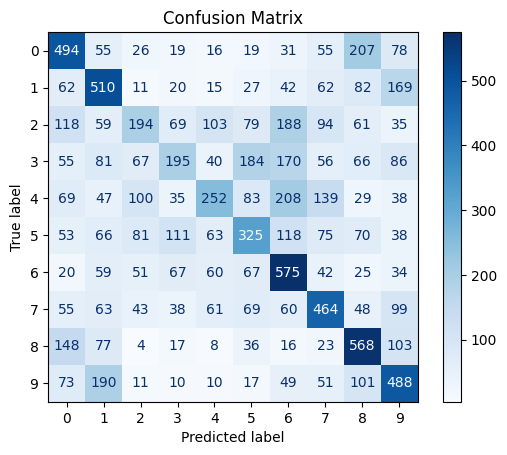

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12, 12))

disp = ConfusionMatrixDisplay.from_estimator(
    pipe,
    x_test,
    y_test,
    display_labels=np.arange(10),
    cmap=plt.cm.Blues,
    normalize=None,
    values_format='d'
)

plt.title("Confusion Matrix")
plt.show()